In [1]:
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal
from probjax.distributions.independent import Independent
from probjax.core import inverse_and_logabsdet, inverse

import haiku as hk
from probjax.nn.coupling import CouplingMLP, Flip

import jax
from jax import numpy as jnp

p = Independent(Normal(jnp.zeros(4), jnp.ones(4)), 1)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [2]:

def affine_bijector(loc_and_scale, x):
    loc, scale = jnp.split(loc_and_scale, 2, axis=-1)
    scale = jax.nn.softplus(scale)
    return loc + scale * x

@hk.without_apply_rng
@hk.transform
def forward(x):
    nn = hk.Sequential([CouplingMLP(2, affine_bijector, 4), Flip(), CouplingMLP(2, affine_bijector, 4), Flip(), CouplingMLP(2, affine_bijector, 4)])
    return nn(x)

init, apply = forward.init, forward.apply

In [12]:
params = init(jax.random.PRNGKey(0), jnp.ones((1,4)))
y = apply(params, jnp.ones((1,4)))

q = TransformedDistribution(p, lambda x: apply(params, x))

In [31]:
@jax.jit
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: apply(params, x))
    return -q.log_prob(x)

In [40]:
loss_fn(params, jnp.ones((10000,4)))

Array([6.481, 6.481, 6.481, ..., 6.481, 6.481, 6.481], dtype=float32)

In [13]:
jax.vmap(inverse_and_logabsdet(lambda x: apply(params, x)))(y)

(Array([[1., 1., 1., 1.]], dtype=float32), Array([0.682], dtype=float32))

In [24]:
samples = q.rsample(jax.random.PRNGKey(0), sample_shape=(1000,))

In [25]:
density = q.log_prob(samples)

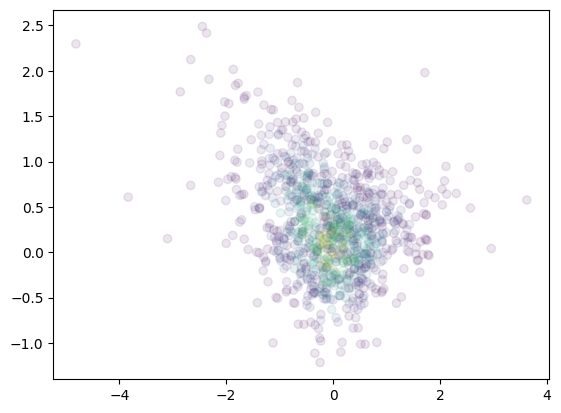

In [26]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,1], samples[:,2], c=jnp.exp(density), alpha=0.1)